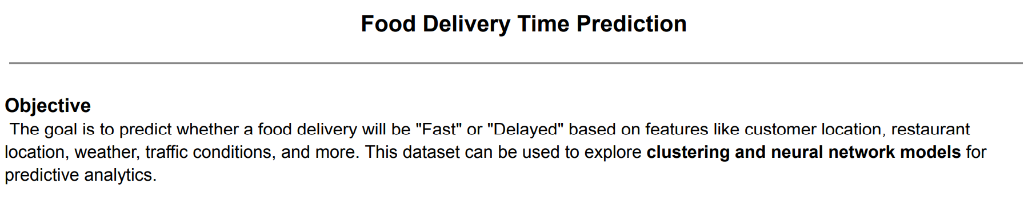

<hr>





In [40]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 

warnings.filterwarnings('ignore')

In [41]:
df = pd.read_csv("Food_Delivery_Time_Prediction.csv")
df

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,ORD0196,"(17.910045, 81.56199)","(18.098924, 87.896124)",23.82,Cloudy,High,8,Medium,Night,Bike,4.7,4.0,50.39,1432.26,66.34
196,ORD0197,"(21.66459, 82.226635)","(16.892341, 80.554716)",6.09,Snowy,Medium,8,Low,Night,Bicycle,3.0,3.6,90.54,1720.25,40.27
197,ORD0198,"(14.575401, 82.55641)","(13.625369, 82.418092)",20.61,Snowy,High,4,Medium,Afternoon,Bike,2.9,3.4,73.20,1356.58,5.10
198,ORD0199,"(12.094497, 82.893369)","(19.135509, 86.659978)",24.06,Rainy,High,9,Low,Night,Car,3.9,4.8,53.94,354.39,85.25


In [42]:
df = df.drop_duplicates()

Label encoding the features

In [43]:
from sklearn.preprocessing import LabelEncoder

cols = ['Weather_Conditions','Order_Priority','Vehicle_Type', 'Traffic_Conditions']
for c in cols:
    df[c] = LabelEncoder().fit_transform(df[c])

In [44]:
df = df.drop(['Order_ID'], axis=1)

Using haversine formulation for calculating location distance 

In [45]:

import pandas as pd
import math
import ast

# Takes each values of columns then, convert the string into the actual Python object
df["Customer_Location"] = df["Customer_Location"].apply(ast.literal_eval) 
df["Restaurant_Location"] = df["Restaurant_Location"].apply(ast.literal_eval)

def haversine(customer_loc, restaurant_loc):
    lat1, lon1 = customer_loc
    lat2, lon2 = restaurant_loc

    R = 6371 # it is average radius of Earth in km.

    # Here converting degrees to radians as python trigonometric functions need radians, not degrees.

    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2]) 

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Using the above formula in the images 

    a = (math.sin(dlat / 2) ** 2 +
         math.cos(lat1) * math.cos(lat2) *
         math.sin(dlon / 2) ** 2)

    c = 2 * math.asin(math.sqrt(a))

    return R * c

""" using the lambda function here which takes row as parameter and go to the haversine function , 
   just like selecting values from index in list we are selecting 
   "Customer_Location"and "Restaurant_Location" from row , The row , Pandas passes it automatically """    

df["locations_distance"] = df.apply( 

    lambda row: haversine(
        row["Customer_Location"],
        row["Restaurant_Location"]
    ),
    axis=1
)

df.head()

,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,locations_distance
0,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,1,2,4,2,Afternoon,2,4.1,3.0,26.22,1321.10,81.54,775.651198
1,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,0,2,8,1,Night,2,4.5,4.2,62.61,152.21,29.02,1042.385597
2,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,2,2,9,0,Night,1,3.3,3.4,48.43,1644.38,64.17,476.220706
3,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,0,1,2,2,Evening,1,3.2,3.7,111.63,541.25,79.23,389.912629
4,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,1,0,6,1,Night,1,3.5,2.8,32.38,619.81,2.34,806.505886


In [46]:
df = df.drop(columns=['Customer_Location','Restaurant_Location'])


Finding median for classification

In [47]:
df['Delivery_Time'].median()

np.float64(72.775)

In [48]:
def check_status(x): 
    if x > 72.775:
        return 1
    else:
        return 0

df["Delivery_Status"] = df["Delivery_Time"].apply(check_status)

In [49]:
df['Rush_Hour'] = df['Order_Time'].apply(
    lambda x: 1 if x in ['Morning', 'Evening'] else 0
)

In [50]:

le = LabelEncoder()

df['Order_Time'] = le.fit_transform(df['Order_Time'])

In [51]:
df.head(5)

,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,locations_distance,Delivery_Status,Rush_Hour
0,1.57,1,2,4,2,0,2,4.1,3.0,26.22,1321.10,81.54,775.651198,0,0
1,21.32,0,2,8,1,3,2,4.5,4.2,62.61,152.21,29.02,1042.385597,0,0
2,6.95,2,2,9,0,3,1,3.3,3.4,48.43,1644.38,64.17,476.220706,0,0
3,13.79,0,1,2,2,1,1,3.2,3.7,111.63,541.25,79.23,389.912629,1,1
4,6.72,1,0,6,1,3,1,3.5,2.8,32.38,619.81,2.34,806.505886,0,0


Using standard scaler for preprocessing the features/data frame.

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[df.columns.drop('Delivery_Status')] = scaler.fit_transform(
    df[df.columns.drop('Delivery_Status')]
)

In [53]:
X_cluster = df.drop('Delivery_Status', axis=1) #for clustering

## **1. K-Means Clustering**

Using the Elbow method.

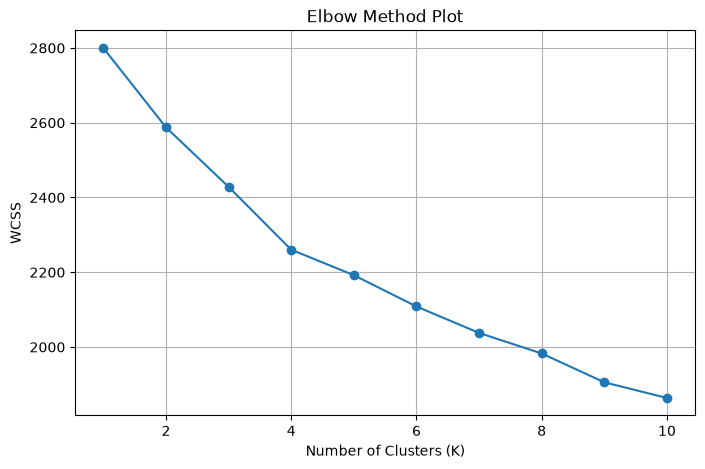

In [54]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1,11):
  kmeans = KMeans(n_clusters=k, random_state=42,n_init=10)

  kmeans.fit(X_cluster)

  wcss.append(kmeans.inertia_)


#Plot

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method Plot")
plt.grid(True)
plt.show()

Using Silehoutte-score for choosing the optimal value of k

In [55]:

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_cluster)
    score = silhouette_score(X_cluster, labels)

    silhouette_scores.append(score)

    print(f"K={k}, Score={score:.4f}")
    

K=2, Score=0.0703
K=3, Score=0.0761
K=4, Score=0.0889
K=5, Score=0.0775
K=6, Score=0.0812
K=7, Score=0.0833
K=8, Score=0.0818
K=9, Score=0.0873
K=10, Score=0.0864


Both methods goes for, Optimal K = 4

Elbow Method → bend around K = 4

Silhouette Score → highest at K = 4

Now traning the model.


In [56]:
from sklearn.cluster import KMeans

model = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

model.fit(X_cluster)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](4, 14)","[[ 0

In [57]:
df['Cluster'] = model.labels_

PCA deccomposition for ploting th data

In [58]:
from sklearn.decomposition import PCA


pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_cluster)


df['PCA1'] = X_pca[:,0]
df['PCA2'] = X_pca[:,1]

2-D Plot

<Axes: xlabel='PCA1', ylabel='PCA2'>

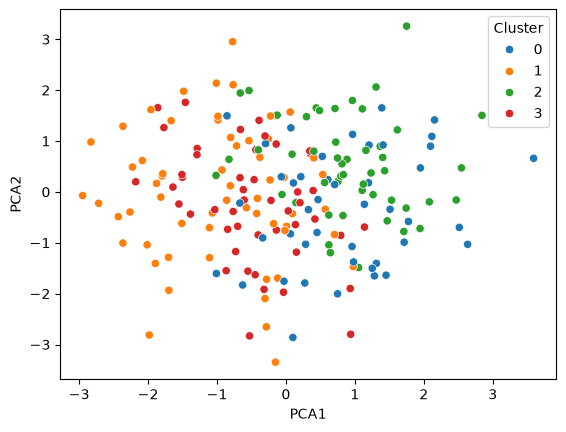

In [59]:
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=df,
    palette='tab10'
)

3-D Plot

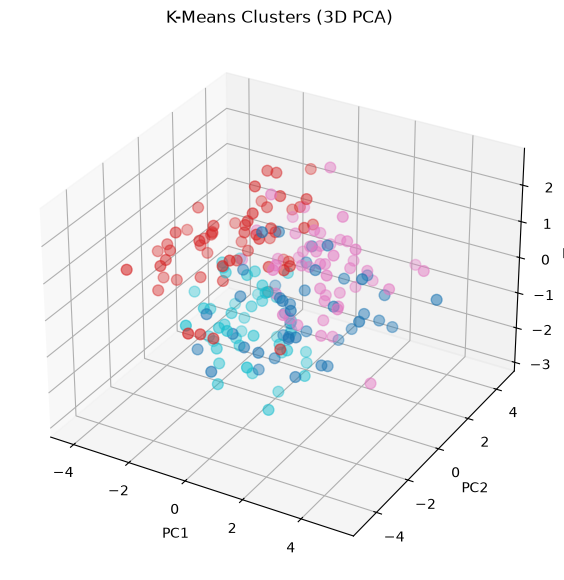

In [60]:


X = df.drop(['Cluster', 'Delivery_Status'], axis=1)

pca = PCA(n_components=3)

X_pca = pca.fit_transform(X)

fig = plt.figure(figsize=(10,7))

ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2],
    c=df['Cluster'],
    cmap='tab10', 
    s=60,
    alpha=0.8
    
)

ax.set_title('K-Means Clusters (3D PCA)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')


plt.show()

**K-Means Clustering Analysis**
*   Applied K-Means Clustering to group delivery records based on delivery-related features.
*   Dataset was standardized before clustering to ensure equal contribution of all features.
*   The Elbow Method and Silhouette Analysis were used to determine the optimal number of clusters.
*   Both methods suggested K = 4 as the optimal number of clusters.
*   The highest Silhouette Score obtained was 0.0889.
*   The low Silhouette Score (K=4, Score=0.0889) suggests weak cluster separation and overlapping patterns among delivery records.




## **2. Hierarchical Clustering**

In [61]:
X = df.drop(['Delivery_Status', 'Cluster'], axis=1)

Making the dendogram for choosing the best value for k

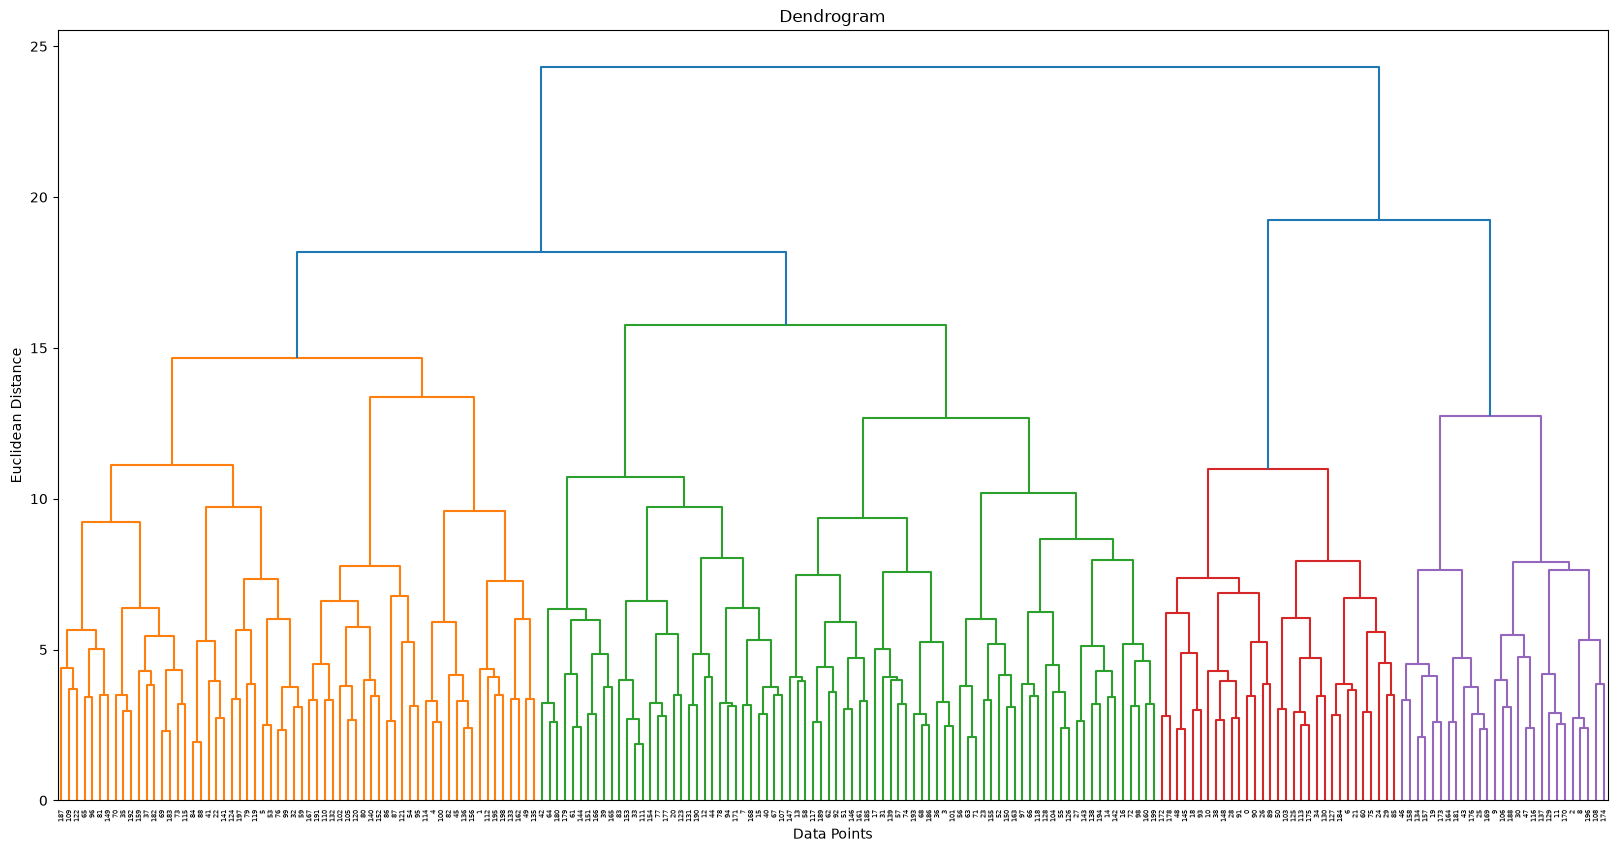

In [62]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

plt.figure(figsize=(20,10))

dendrogram(
    linkage(X, method='ward')
)

plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")

plt.show()

Cutting the dendrogram at 15–18(approx) gives 4 clusters.
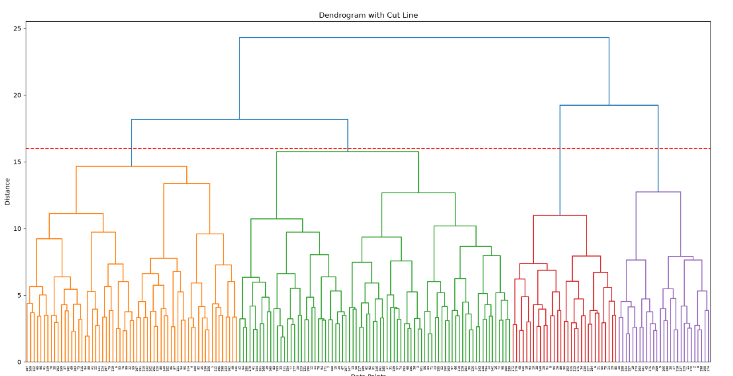

Using Agglomerative Clustering to the dataset

In [63]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=4,
    linkage='ward'
)

df['HC_Cluster'] = hc.fit_predict(
    df.drop(['Cluster', 'Delivery_Status'], axis=1)
)

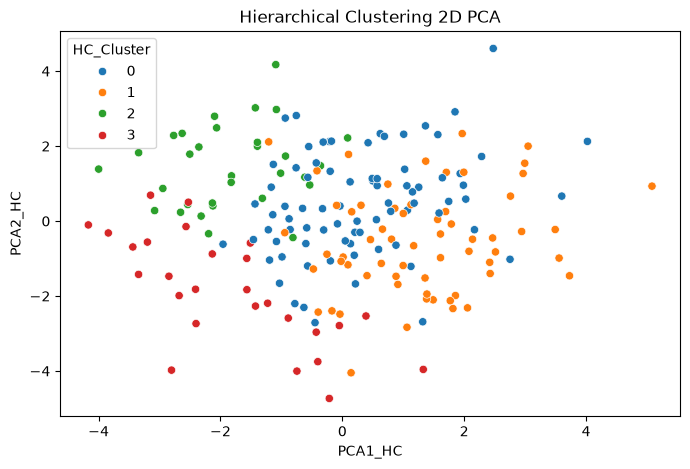

In [64]:


# Features used for clustering
X = df.drop(['Cluster', 'Delivery_Status', 'HC_Cluster'], axis=1)


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)


df['PCA1_HC'] = X_pca[:, 0]
df['PCA2_HC'] = X_pca[:, 1]

plt.figure(figsize=(8,5))
sns.scatterplot(
    x='PCA1_HC',
    y='PCA2_HC',
    hue='HC_Cluster',
    data=df,
    palette='tab10'
)

plt.title("Hierarchical Clustering 2D PCA")
plt.show()

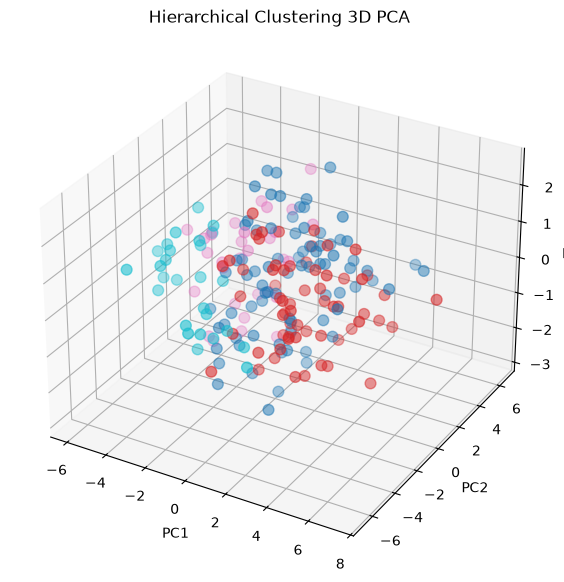

In [65]:

X = df.drop(['Cluster', 'Delivery_Status', 'HC_Cluster'], axis=1)

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2],
    c=df['HC_Cluster'],
    cmap='tab10',
    s=60,
    alpha=0.8
)

ax.set_title('Hierarchical Clustering 3D PCA')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')


plt.show()

### Hierarchical Clustering Analysis

- Applied Agglomerative Hierarchical Clustering using Ward linkage.
- A dendrogram was used to visualize the hierarchical structure and determine the optimal number of clusters.
- Four clusters were selected based on dendrogram analysis.
- Provide better visuals then K-mean.


# **3.DBSCAN**

In [66]:
from sklearn.cluster import DBSCAN

In [67]:
from sklearn.preprocessing import StandardScaler

X = df.drop(['Delivery_Status', 'Cluster'], axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

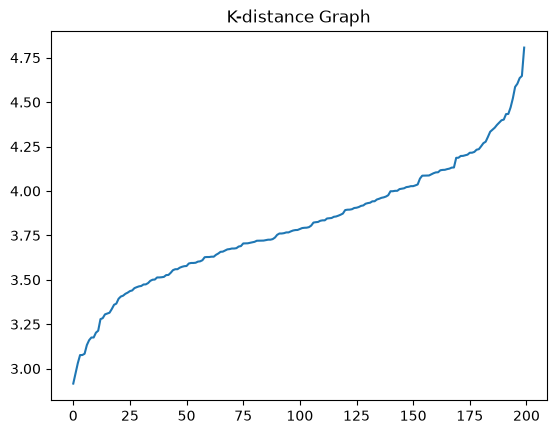

In [68]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)

distances, _ = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, -1])

plt.plot(distances)
plt.title("K-distance Graph")
plt.show()

- The curve is very smooth → no sharp “clear elbow”
- The rise is gradual, then slightly steeper near ~4.3–4.7
- This suggests: No strong density separation in data

In [69]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=4.5, min_samples=5)
clusters = dbscan.fit_predict(X_scaled)

In [70]:
df['DBSCAN_Cluster'] = clusters

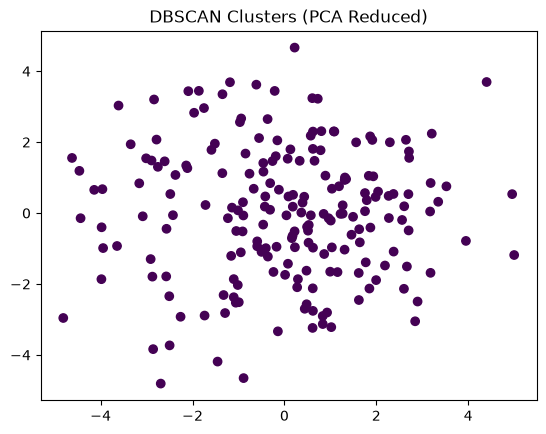

In [71]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis')
plt.title("DBSCAN Clusters (PCA Reduced)")
plt.show()

In [77]:
print(set(df['DBSCAN_Cluster']))
print((df['DBSCAN_Cluster'] == -1).sum())

{0}
0


# **DBSCAN Analysis**

- The k-distance graph lacked a clear elbow and the PCA visualization showed no dense regions. This indicates the dataset does not satisfy DBSCAN’s density assumptions.

## Why its happning ?

**DBSCAN needs:**

- Dense regions 
- Clear separation 

**Our data:**

- Uniform density 
- No natural grouping 

- **Clustering algorithms don’t create clusters — they only detect structure. If structure doesn’t exist → algorithm fails**



# **4. Artificial Neural Network.(ANN)**

In [72]:
from sklearn.model_selection import train_test_split


X = df.drop(['Delivery_Status', 'Delivery_Time'], axis=1)

y = df['Delivery_Status']



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In my neural network, I am using one input layer, three hidden layers, and one output layer. For the hidden layer, we are using activation as ReLU, and where in the output layer we are using classification, so we are using sigmoid activation function. Loss, for loss we are using binary cross entropy, and optimizer, Adam.

In [73]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input



model = Sequential([

    Input(shape=(X_train.shape[1],)),
    Dense(8, activation='relu'),
    Dense(6, activation='relu'),
    Dense(4, activation='relu'),
    Dense(1, activation='sigmoid')
])



model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)


Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.5156 - loss: 0.7279 - val_accuracy: 0.5625 - val_loss: 0.6892
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5078 - loss: 0.7191 - val_accuracy: 0.6875 - val_loss: 0.6839
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5078 - loss: 0.7109 - val_accuracy: 0.6875 - val_loss: 0.6804
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5156 - loss: 0.7052 - val_accuracy: 0.6875 - val_loss: 0.6784
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5391 - loss: 0.6996 - val_accuracy: 0.7188 - val_loss: 0.6775
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5391 - loss: 0.6950 - val_accuracy: 0.6875 - val_loss: 0.6765
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5469 - loss: 0.6918 - val_accuracy: 0.6562 - val_loss: 0.6760
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5391 - loss: 0.6873 - val_accuracy: 0.6250 - val_loss: 0.

We are applying a threshold of 0.5 here,
- if value > 0.5 → 1
- else value ≤ 0.5 → 0

In [74]:
loss, acc = model.evaluate(X_test, y_test, verbose=1)
print(acc)

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5500 - loss: 0.7913 
0.550000011920929
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


In [75]:
from sklearn.metrics import confusion_matrix, classification_report

# Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)


# Classification Report
print(
    classification_report(
        y_test,
        y_pred
    )
)

[[10  9]
 [ 9 12]]
              precision    recall  f1-score   support

           0       0.53      0.53      0.53        19
           1       0.57      0.57      0.57        21

    accuracy                           0.55        40
   macro avg       0.55      0.55      0.55        40
weighted avg       0.55      0.55      0.55        40



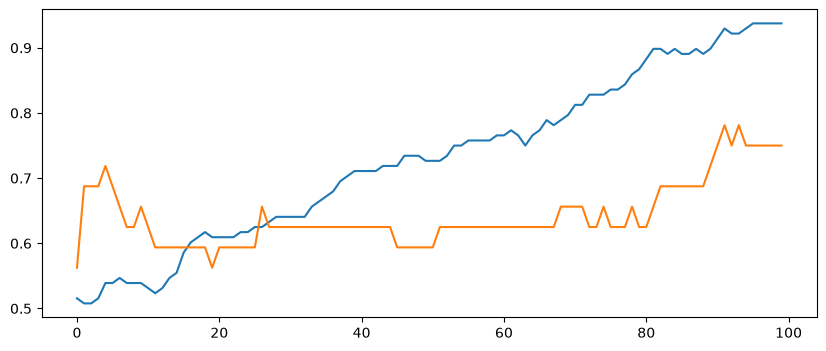

In [76]:


plt.figure(figsize = (10,4))
plt.plot(history.history['accuracy'],label = "train Acc")
plt.plot(history.history['val_accuracy'],label = "val Acc")

## `ANN - Analysis (For one scenario.) `

### Model Performance

| Metric   | Value  |
| -------- | ------ |
| Accuracy | 75%    |
| Loss     | 0.59 |


### Confusion Matrix

| Actual \ Predicted | Fast (0) | Delayed (1) |
| ------------------ | -------- | ----------- |
| Fast (0)           | 13       | 6          |
| Delayed (1)        | 4        | 17          |

- 13 → Correctly predicted 0
- 6 → Actually 0, but predicted 1 (mistake)
- 4 → Actually 1, but predicted 0 (mistake)
- 17 → Correctly predicted 1

### Observations

- It's a fairly balanced model according to me
- Gets 3 out of 4 predictions right
- Is better at detecting class 1 than class 0
- Makes more mistakes on class 0

<br>
<hr>

#### **Why the model gives slightly different results each time?**

While working on the neural network, I observed that the confusion matrix and classification report were slightly different every time I ran the model, even though the data and model structure remained the same.

This happens because neural networks involve some level of randomness during training. For example, the model starts with random initial values (weights), and the data is often shuffled during the learning process. Due to this, the model learns slightly differently each time it runs.

eg: 
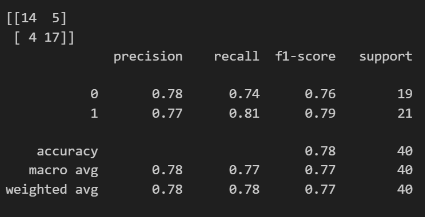

<hr>

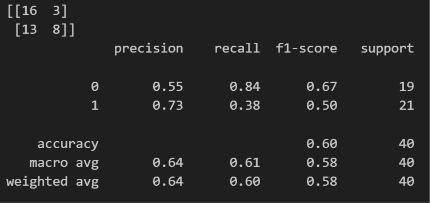